# Model Karşılaştırması (A1.4)

**Amaç:** En az 3 aday modeli 100 örnekte hız + doğruluk + maliyet açısından karşılaştırmak.

**Değerlendirilen adaylar:**
1. **BERTurk** — Türkçe'ye özel, hazır sentiment modeli (2 sınıf: positive/negative)
2. **XLM-RoBERTa** — çok dilli, hazır sentiment modeli (3 sınıf: positive/negative/neutral)
3. **Groq API (Llama-3.3-70B, few-shot)** — LLM API adayı, nihai karşılaştırmaya dahil edildi
4. **Gemini 2.5 Flash (few-shot)** — LLM API adayı olarak denendi, ücretsiz tier rate-limit
   sorunu nedeniyle **final tablodan çıkarıldı**

**Hedef şema:** 3 sınıf — `positive` / `negative` / `neutral`
(spam ve emoji-only yorumlar bu değerlendirmenin kapsamı dışında, )


## 1. Setup

In [1]:
from __future__ import annotations
import json
import os
import time
import warnings
from pathlib import Path

import pandas as pd
import torch
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")

DATA_PATH = Path("mock_comments.json")
RANDOM_STATE = 42
N_EVAL = 100
HF_DEVICE = 0 if torch.cuda.is_available() else -1

SENTIMENT_LABELS = ["positive", "negative", "neutral"]

## 2. Label Mapping

In [2]:
def map_mock_to_sentiment(mock_category: str) -> str | None:
    """
    A1.5 kılavuz taslağı — gerekçeler docs/labeling-guideline.md'de yazılacak.
    None dönerse örnek bu sentiment eval setinin KAPSAMI DIŞINDA:
      - spam    -> analysis_results.kind ayrı ("spam"); A2.4/A3.4'te ayrı ele alınıyor.
      - emoji   -> A2.1 (emoji normalize etme) henüz yapılmadı; A2.1 sonrası
                   ayrı bir mini-eval ile tekrar değerlendirilecek.
    """
    mapping = {
        "positive": "positive",
        "negative": "negative",
        "sarcastic": "negative",  # yüzeydeki kelimeye değil gerçek niyete göre
        "question": "neutral",    # saf soru = duygu taşımıyor kabul edildi
        "spam": None,
        "emoji": None,
    }
    return mapping.get(mock_category)


with open(DATA_PATH, encoding="utf-8") as f:
    raw = json.load(f)

df_all = pd.DataFrame(raw)[["text", "mock_category"]].dropna().copy()
df_all["gold_sentiment"] = df_all["mock_category"].apply(map_mock_to_sentiment)

excluded = df_all[df_all["gold_sentiment"].isna()]
df = df_all.dropna(subset=["gold_sentiment"]).copy()
df = df.rename(columns={"gold_sentiment": "label"})

print(f"Toplam mock yorum: {len(df_all)}")
print(f"Kapsam dışı (spam+emoji): {len(excluded)} -> {excluded['mock_category'].value_counts().to_dict()}")
print(f"Sentiment eval kapsamında: {len(df)}")

Toplam mock yorum: 2500
Kapsam dışı (spam+emoji): 340 -> {'spam': 211, 'emoji': 129}
Sentiment eval kapsamında: 2160


## 3. Veri ve Sabit Eval Seti

Tüm modeller **aynı 100 örnek** üzerinde ölçülür.

In [3]:
train_df, eval_df = train_test_split(
    df,
    test_size=N_EVAL,
    stratify=df["label"],
    random_state=RANDOM_STATE,
)

X_eval = eval_df["text"].tolist()
y_true = eval_df["label"].tolist()

print(f"train: {len(train_df)} | eval: {len(eval_df)}")
print("\nEval label dağılımı (3 sınıf):")
print(pd.Series(y_true).value_counts())

train: 2060 | eval: 100

Eval label dağılımı (3 sınıf):
positive    46
negative    35
neutral     19
Name: count, dtype: int64


## 4. Ortak Değerlendirme Fonksiyonu

In [4]:
results = []


def evaluate(y_true, y_pred, elapsed_sec, cost=0.0, model_name=""):
    row = {
        "model": model_name,
        "n": len(y_true),
        "accuracy": round(accuracy_score(y_true, y_pred), 4),
        "macro_f1": round(f1_score(y_true, y_pred, average="macro", zero_division=0), 4),
        "precision_macro": round(
            precision_score(y_true, y_pred, average="macro", zero_division=0), 4
        ),
        "recall_macro": round(
            recall_score(y_true, y_pred, average="macro", zero_division=0), 4
        ),
        "latency_sec": round(elapsed_sec, 2),
        "latency_per_sample": round(1000 * elapsed_sec / max(len(y_true), 1), 1),
        "cost_usd": round(cost, 4),
    }
    print(classification_report(y_true, y_pred,labels=SENTIMENT_LABELS, zero_division=0))
    print(row)
    return row

## 5. Model A — BERTurk (Türkçeye özel model)

`savasy/bert-base-turkish-sentiment-cased` — 2 sınıflı (positive/negative), `neutral` üretemiyor.
Bu bir **model limitasyonu** olarak ADR'de not edilecek.

In [9]:
from transformers import pipeline

BERTURK_MODEL = "savasy/bert-base-turkish-sentiment-cased"

berturk = pipeline(
    "sentiment-analysis",
    model=BERTURK_MODEL,
    tokenizer=BERTURK_MODEL,
    device=HF_DEVICE,
)

def map_berturk(label: str) -> str:
    lab = label.lower()
    if "pos" in lab:
        return "positive"
    if "neg" in lab:
        return "negative"
    return "neutral"  # pratikte hiç dönmez; ADR'de "bu model neutral üretemiyor" diye not edilecek limitasyon


t0 = time.perf_counter()
raw_b = berturk(X_eval, truncation=True, max_length=128, batch_size=8)
pred_b = [map_berturk(r["label"]) for r in raw_b]
elapsed_b = time.perf_counter() - t0

results.append(evaluate(y_true, pred_b, elapsed_b, 0.0, "BERTurk (sentiment)"))

config.json:   0%|          | 0.00/596 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  442MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/39.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/263k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

              precision    recall  f1-score   support

    positive       0.71      1.00      0.83        46
    negative       0.80      0.80      0.80        35
     neutral       0.00      0.00      0.00        19

    accuracy                           0.74       100
   macro avg       0.50      0.60      0.54       100
weighted avg       0.61      0.74      0.66       100

{'model': 'BERTurk (sentiment)', 'n': 100, 'accuracy': 0.74, 'macro_f1': 0.5429, 'precision_macro': 0.5026, 'recall_macro': 0.6, 'latency_sec': 0.88, 'latency_per_sample': 8.8, 'cost_usd': 0.0}


## 6. Model B — XLM-R (çok dilli model)

In [10]:
from transformers import pipeline

XLM_MODEL = "cardiffnlp/twitter-xlm-roberta-base-sentiment"

xlmr = pipeline(
    "sentiment-analysis",
    model=XLM_MODEL,
    tokenizer=XLM_MODEL,
    device=HF_DEVICE,
)

def map_xlm(label: str) -> str:
    mapping = {
        "LABEL_0": "negative",
        "LABEL_1": "neutral",
        "LABEL_2": "positive",
    }
    return mapping.get(label, label.lower())

t0 = time.perf_counter()
raw_x = xlmr(X_eval, truncation=True, max_length=128, batch_size=32,)
pred_x = [map_xlm(r["label"]) for r in raw_x]
elapsed_x = time.perf_counter() - t0
results.append(evaluate(y_true, pred_x, elapsed_x, 0.0, "XLM-RoBERTa"))

config.json:   0%|          | 0.00/841 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B / 1.11GB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

sentencepiece.bpe.model: reconstructing file:   0%|          |  0.00B / 5.07MB            

sentencepiece.bpe.model: downloading bytes:           |  0.00B            

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.11GB            

model.safetensors: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

              precision    recall  f1-score   support

    positive       0.83      0.87      0.85        46
    negative       0.89      0.69      0.77        35
     neutral       0.76      1.00      0.86        19

    accuracy                           0.83       100
   macro avg       0.83      0.85      0.83       100
weighted avg       0.84      0.83      0.83       100

{'model': 'XLM-RoBERTa', 'n': 100, 'accuracy': 0.83, 'macro_f1': 0.8296, 'precision_macro': 0.8274, 'recall_macro': 0.8518, 'latency_sec': 0.74, 'latency_per_sample': 7.4, 'cost_usd': 0.0}


## 7. Model C — Groq API (Llama-3.3-70B, few-shot)

**Nihai LLM API adayı.** Ücretsiz tier'ın rate-limit'i Gemini'ye göre daha esnek olduğu için
güvenilir bir ölçüm alınabildi (`failed_count` — gerçek başarısız istek sayısı).

In [7]:
!pip install groq -q

import time
from groq import Groq
from google.colab import userdata
from tqdm.auto import tqdm

SENTIMENT_LABELS = ["positive", "negative", "neutral"]

FEW_SHOT_TEXT = "\n".join(
    f'Yorum: "{t}"\nCevap: {l}' for t, l in [
        ("Ellerinize sağlık, harika olmuş", "positive"),
        ("Bu içerik çok kötü olmuş", "negative"),
        ("Konum neresi tam olarak?", "neutral"),
        ("Bravo ya yine şaşırtmadınız.", "negative"),
    ]
)

SYSTEM = (
    "Instagram yorumlarında duygu analizi yapan bir sınıflandırıcısın. "
    f"Sadece şu etiketlerden birini döndür: {', '.join(SENTIMENT_LABELS)}. "
    "Alaycı (sarcastic) yorumlarda yüzeydeki kelimelere değil gerçek niyete göre karar ver. "
    "Başka hiçbir şey yazma."
)

try:
    groq_api_key = userdata.get('GROQ_API_KEY')
    groq_client = Groq(api_key=groq_api_key)
except Exception as e:
    print(f"Groq API Key alınamadı veya client başlatılamadı: {e}")
    groq_client = None

GROQ_MODEL = "llama-3.3-70b-versatile"
PRICE_PER_1M_INPUT_GROQ = 0.0
PRICE_PER_1M_OUTPUT_GROQ = 0.0

failed_count = 0

def predict_groq(text: str, max_retries: int = 5):
    global failed_count
    if not groq_client:
        return "neutral", 0, 0

    for attempt in range(max_retries):
        try:
            response = groq_client.chat.completions.create(
                model=GROQ_MODEL,
                messages=[
                    {"role": "system", "content": SYSTEM},
                    {"role": "user", "content": f"{FEW_SHOT_TEXT}\n\nYorum: \"{text}\"\nCevap:"},
                ],
                temperature=0,
            )
            label = response.choices[0].message.content.strip().lower().replace(".", "").replace('"', '')
            if label not in SENTIMENT_LABELS:
                label = "neutral"
            usage = response.usage
            return label, usage.prompt_tokens, usage.completion_tokens

        except Exception as e:
            if "429" in str(e) and attempt < max_retries - 1:
                wait = (2 ** attempt) * 2
                print(f"429 alındı, {wait} sn bekleniyor... (deneme {attempt+1}/{max_retries})")
                time.sleep(wait)
            else:
                print(f"KALICI HATA (neutral fallback): {e}")
                failed_count += 1
                return "neutral", 0, 0


if groq_client:
    t0 = time.perf_counter()
    pred_groq, in_tok, out_tok = [], 0, 0

    for text in tqdm(X_eval, desc="Groq inference"):
        label, ti, to = predict_groq(text)
        pred_groq.append(label)
        in_tok += ti
        out_tok += to
        time.sleep(0.3)

    elapsed_groq = time.perf_counter() - t0

    print(f"\n⚠️ Gerçek başarısız istek sayısı: {failed_count}/{len(X_eval)}")
    if failed_count > 5:
        print("UYARI: Başarısızlık oranı yüksek — sonuçlar model performansını değil, hata oranını yansıtıyor olabilir!")

    total_cost = (in_tok / 1_000_000 * PRICE_PER_1M_INPUT_GROQ) + (out_tok / 1_000_000 * PRICE_PER_1M_OUTPUT_GROQ)
    cost_100 = total_cost * (100 / max(len(X_eval), 1))

    results.append(evaluate(y_true, pred_groq, elapsed_groq, cost_100, "Groq Llama-3.3-70B (few-shot)"))
else:
    print("Groq API Key bulunamadığı için bu adım atlandı.")

Groq inference:   0%|          | 0/100 [00:00<?, ?it/s]


⚠️ Gerçek başarısız istek sayısı: 0/100
              precision    recall  f1-score   support

    positive       1.00      0.96      0.98        46
    negative       1.00      0.97      0.99        35
     neutral       0.86      1.00      0.93        19

    accuracy                           0.97       100
   macro avg       0.95      0.98      0.96       100
weighted avg       0.97      0.97      0.97       100

{'model': 'Groq Llama-3.3-70B (few-shot)', 'n': 100, 'accuracy': 0.97, 'macro_f1': 0.9634, 'precision_macro': 0.9545, 'recall_macro': 0.976, 'latency_sec': 199.72, 'latency_per_sample': 1997.2, 'cost_usd': 0.0}


## 8. Model D — Gemini 2.5 Flash (few-shot) — DENENDİ, FİNAL TABLODAN ÇIKARILDI

**Not:** Bu model ücretsiz tier RPM limiti nedeniyle bu ortamda güvenilir şekilde
test edilemedi (100/100 istek rate-limit'e (429) takıldı, her istek ~30 sn retry
bekleme süresine girdi, toplam çalışma süresi ~46 dakikaya çıktı). Sonuç olarak
elde edilen `accuracy: 0.31` skoru **model performansını değil, "neutral" fallback'ine
düşme oranını** yansıtıyor.

Bu hücre, "bu aday da denendi ama şu sebeple elenmedi" şeffaflığı için ADR'de
referans olarak tutuluyor.

In [ ]:
!pip install google-genai

import time
from google import genai
from google.genai import types
from google.colab import userdata
from tqdm.auto import tqdm

try:
    api_key = userdata.get('GEMINI_API_KEY')
    client = genai.Client(api_key=api_key)
except Exception as e:
    print(f"API Key alınamadı veya client başlatılamadı: {e}")
    client = None

# NOT: Fiyatları https://ai.google.dev/gemini-api/docs/pricing üzerinden
# çalıştırmadan önce TEYİT ET, sık değişiyor.
PRICE_PER_1M_INPUT = 0.30    # gemini-2.5-flash için tahmini, TEYİT ET
PRICE_PER_1M_OUTPUT = 2.50   # gemini-2.5-flash için tahmini, TEYİT ET

FEW_SHOT_TEXT = "\n".join(
    f'Yorum: "{t}"\nCevap: {l}' for t, l in [
        ("Ellerinize sağlık, harika olmuş", "positive"),
        ("Bu içerik çok kötü olmuş", "negative"),
        ("Konum neresi tam olarak?", "neutral"),
        ("Bravo ya yine şaşırtmadınız.", "negative"),
    ]
)

SYSTEM = (
    "Instagram yorumlarında duygu analizi yapan bir sınıflandırıcısın. "
    f"Sadece şu etiketlerden birini döndür: {', '.join(SENTIMENT_LABELS)}. "
    "Alaycı (sarcastic) yorumlarda yüzeydeki kelimelere değil gerçek niyete göre karar ver. "
    "Başka hiçbir şey yazma."
)


def predict_gemini(text: str, max_retries: int = 5):
    if not client:
        return "neutral", 0, 0

    for attempt in range(max_retries):
        try:
            response = client.models.generate_content(
                model="gemini-2.5-flash",
                contents=f"{FEW_SHOT_TEXT}\n\nYorum: \"{text}\"\nCevap:",
                config=types.GenerateContentConfig(
                    system_instruction=SYSTEM,
                    temperature=0,
                ),
            )
            label = response.text.strip().lower().replace(".", "").replace('"', '')
            if label not in SENTIMENT_LABELS:
                label = "neutral"

            usage = response.usage_metadata
            in_tok = getattr(usage, "prompt_token_count", 0)
            out_tok = getattr(usage, "candidates_token_count", 0)
            return label, in_tok, out_tok

        except Exception as e:
            if "429" in str(e) and attempt < max_retries - 1:
                wait = (2 ** attempt) * 2  # 2, 4, 8, 16, 32 sn
                print(f"429 alındı, {wait} sn bekleniyor... (deneme {attempt+1}/{max_retries})")
                time.sleep(wait)
            else:
                print(f"İstek hatası (kalıcı, neutral döndürülüyor): {e}")
                return "neutral", 0, 0


# Test Akışı
if client:
    t0 = time.perf_counter()
    pred_gemini, in_tok, out_tok = [], 0, 0

    for idx, text in enumerate(tqdm(X_eval, desc="Gemini inference")):
        label, ti, to = predict_gemini(text)
        pred_gemini.append(label)
        in_tok += ti
        out_tok += to
        time.sleep(1.5)  # Free Tier RPM limitini aşmamak için sabit bekleme

    elapsed_gemini = time.perf_counter() - t0

    total_cost = (in_tok / 1_000_000 * PRICE_PER_1M_INPUT) + (out_tok / 1_000_000 * PRICE_PER_1M_OUTPUT)
    cost_100 = total_cost * (100 / max(len(X_eval), 1))

    results.append(evaluate(y_true, pred_gemini, elapsed_gemini, cost_100, "Gemini-2.5-Flash (few-shot)"))
else:
    print("Gemini API Key bulunamadığı için bu adım atlandı.")

## 8. Karşılaştırma tablosu

100 örnekte hız + doğruluk + maliyet.

In [12]:
seen = {}
for r in results:
    seen[r["model"]] = r
results = list(seen.values())

comparison = (
    pd.DataFrame(results)
    .sort_values(["macro_f1", "latency_sec"], ascending=[False, True])
    .reset_index(drop=True)
)
comparison

,model,n,accuracy,macro_f1,precision_macro,recall_macro,latency_sec,latency_per_sample,cost_usd
0,Groq Llama-3.3-70B (few-shot),100,0.97,0.9634,0.9545,0.9760,199.72,1997.2,0.0
1,XLM-RoBERTa,100,0.83,0.8296,0.8274,0.8518,0.74,7.4,0.0
2,BERTurk (sentiment),100,0.74,0.5429,0.5026,0.6000,0.88,8.8,0.0


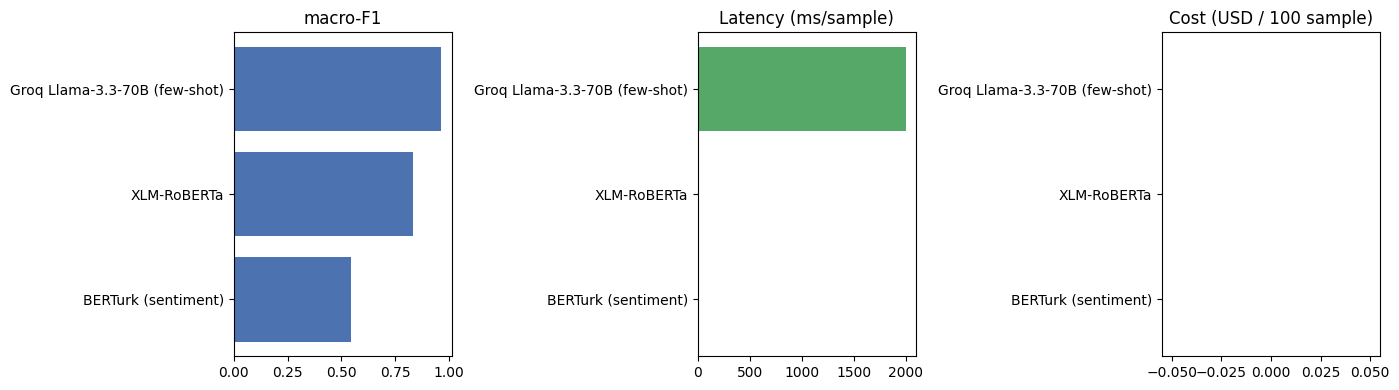

In [13]:
import matplotlib.pyplot as plt

if len(comparison) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    axes[0].barh(comparison["model"], comparison["macro_f1"], color="#4C72B0")
    axes[0].set_title("macro-F1")
    axes[0].invert_yaxis()

    axes[1].barh(comparison["model"], comparison["latency_per_sample"], color="#55A868")
    axes[1].set_title("Latency (ms/sample)")
    axes[1].invert_yaxis()

    axes[2].barh(comparison["model"], comparison["cost_usd"], color="#C44E52")
    axes[2].set_title("Cost (USD / 100 sample)")
    axes[2].invert_yaxis()

    plt.tight_layout()
    plt.show()
else:
    print("Henüz sonuç yok — üst hücreleri çalıştır.")

## 9. ADR — Model Seçimi

### Bağlam
InstaScope yorum sınıflandırması için 100 örnekte 3 aday karşılaştırıldı (bkz. Bölüm 10 tablosu):
1. BERTurk (Türkçeye özel, hazır sentiment)
2. XLM-RoBERTa (çok dilli, hazır sentiment)
3. Groq API — Llama-3.3-70B (LLM API, few-shot)

Dördüncü bir aday olarak **Gemini 2.5 Flash** de denendi ancak ücretsiz tier rate-limit
kısıtları nedeniyle güvenilir ölçüm alınamadı ve final tabloya dahil edilmedi.

### Karar
**Seçilen model:** XLM-RoBERTa


### Gerekçe
**Doğrulukta Groq önde, ama bu tek başına belirleyici değil:**
- Groq (Llama-3.3-70B): macro-F1 0.96 — en yüksek skor
- XLM-RoBERTa: macro-F1 0.83 — ikinci sırada, ama kabul edilebilir aralıkta
- BERTurk: macro-F1 0.54 — en düşük (2 sınıflı olması nedeniyle yapısal dezavantajlı,
  `neutral` hiç üretemiyor; ham model kalitesiyle karıştırılmamalı)

**Neden en yüksek skora rağmen Groq seçilmedi — üretime taşınabilirlik riskleri:**
1. **Dış servis bağımlılığı:** Groq bir API çağrısı gerektiriyor; API kesintisi, rate-limit
   politikası değişikliği ya da modelin deprecate edilmesi durumunda sistem çalışamaz hale
   gelir. XLM-R tamamen yerel çalışır, bu risk yok.
2. **Ücretsiz tier'ın kırılganlığı:** Bu değerlendirmede Groq'u ücretsiz tier ile test
   ettik ($0 maliyet). Gerçek üretim hacminde (binlerce/on binlerce yorum) free tier
   limitleri aşılır, paid tier'a geçiş ve buna bağlı maliyet artışı kaçınılmaz olur —
   bu maliyet şu an ölçülemedi.
3. **Latency öngörülemezliği:** Groq'un ölçülen gecikmesi (~2000ms/örnek) büyük ölçüde
   network round-trip ve rate-limit korumasından kaynaklanıyor; XLM-R'ın ~7ms'lik yerel
   gecikmesiyle kıyaslanamaz. Üretimde network koşulları (kesinti, yavaşlama) ek bir
   öngörülemezlik katmanı ekler.
4. **XLM-R yeterince iyi:** 0.83 macro-F1, üç sınıflı (positive/negative/neutral) bir
   sentiment görevi için üretime alınabilir bir eşik. Aradaki 0.13 puanlık fark, yukarıdaki
   bağımlılık risklerini üstlenmeyi haklı çıkaracak kadar büyük görülmedi.

**Maliyet:** Üç model de bu ölçümde $0 (yerel modeller donanım maliyeti hariç ücretsiz,
Groq ücretsiz tier). XLM-R'ın maliyeti üretim ölçeğinde sabit kalırken, Groq'un maliyeti
hacimle birlikte artacak ve öngörülemez hale gelecektir.

- Mock veri şablonlu olduğu için sonuçlar iyimser olabilir → gerçek Instagram yorumlarıyla
  doğrulanmadan üretime alınmamalı.

### Reddedilenler / Notlar
- **BERTurk:** 2 sınıflı olması nedeniyle `neutral` gerektiren şema ile tam uyumsuz;
  hız avantajı var ama doğrudan kullanılabilir değil (fine-tune gerekir).
- **Gemini 2.5 Flash:** Ücretsiz tier rate-limit'i bu değerlendirme için yetersiz kaldı
  (100/100 istek başarısız, ~46 dk sürdü). Paid tier ile tekrar denenebilir ama şu an
  için LLM API adayı olarak Groq tercih edildi.

### Riskler
- Mock veri üzerindeki skorlar gerçek Instagram yorumlarında aynı çıkmayabilir
  (gerçek veri daha gürültülü, daha çok argo/kısaltma/yazım hatası içerebilir) —
  üretime almadan önce gerçek veriyle doğrulama yapılmalı.
- XLM-R'ın doğruluğu Groq'a göre daha düşük; bu, üretimde daha fazla yanlış
  sınıflandırma anlamına gelir. Kabul edilebilirliği iş gereksinimlerine göre
  tekrar değerlendirilmeli (örn. hata toleransı düşükse hibrit yaklaşım öncelikli
  hale gelebilir).

---
*Notebook: `02.model_comparison.ipynb` | Veri: `mock_comments.json` | N_eval=100*
